In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
df = pd.read_excel('../../../data/online+retail/Online Retail.xlsx')
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [3]:
(df['Quantity'] < 0).sum()

np.int64(10624)

In [4]:
df = df.dropna()
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [5]:
df['total_price'] = df['Quantity'] * df['UnitPrice']

In [6]:
df = df[df['total_price'] > 0]


In [7]:
df_pedidos = df.groupby(
    ['CustomerID', 'InvoiceNo', 'InvoiceDate'],
    as_index=False
).agg({
    'total_price': 'sum'
})

df_pedidos.head(5)


,CustomerID,InvoiceNo,InvoiceDate,total_price
0,12346.0,541431,2011-01-18 10:01:00,77183.60
1,12347.0,537626,2010-12-07 14:57:00,711.79
2,12347.0,542237,2011-01-26 14:30:00,475.39
3,12347.0,549222,2011-04-07 10:43:00,636.25
4,12347.0,556201,2011-06-09 13:01:00,382.52


In [8]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [9]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
total_price           float64
dtype: object

# **AJUSTAR AL MODELO DE DATOS**

In [10]:
import pandas as pd
import numpy as np
from difflib import SequenceMatcher
from datetime import datetime


class DatasetMapper:
    """
    Mapea automáticamente columnas de un dataset a un esquema objetivo
    usando similitud de texto y validación de tipos de datos.
    """
    
    def __init__(self):
        # Modelo de datos objetivo para segmentación de clientes
        self.target_schema = {
            'id_usuario': {
                'type': 'string',
                'aliases': ['user_id', 'usuario', 'cliente', 'customer_id', 
                           'client_id', 'user', 'cliente_id', 'id_cliente']
            },
            'id_pedido': {
                'type': 'string',
                'aliases': ['order_id', 'pedido', 'orden', 'order', 
                           'num_pedido', 'numero_pedido', 'id_orden']
            },
            'total_pedido': {
                'type': 'number',
                'aliases': ['total', 'amount', 'importe', 'total_price', 'totalprice',
                           'monto', 'valor', 'total_order', 'importe_total', 'total_amount',
                           'order_total', 'order_amount', 'invoice_total', 'grand_total']
            },
            'fecha_pedido': {
                'type': 'date',
                'aliases': ['fecha', 'date', 'created_at', 'order_date', 
                           'fecha_orden', 'timestamp', 'fecha_creacion']
            }
        }
    
    def _calculate_similarity(self, str1, str2):
        """Calcula similitud entre dos strings"""
        str1 = str1.lower().replace('_', '').replace('-', '').replace(' ', '')
        str2 = str2.lower().replace('_', '').replace('-', '').replace(' ', '')
        
        # Coincidencia exacta
        if str1 == str2:
            return 1.0
        
        # Contiene
        if str1 in str2 or str2 in str1:
            return 0.85
        
        # Similitud de secuencia
        return SequenceMatcher(None, str1, str2).ratio()
    
    def _validate_type(self, series, expected_type):
        """Valida que una serie coincida con el tipo esperado"""
        if len(series) == 0:
            return 0.5
        
        # Tomar muestra de valores no nulos
        sample = series.dropna().head(10)
        if len(sample) == 0:
            return 0.5
        
        valid_count = 0
        
        for value in sample:
            if expected_type == 'number':
                try:
                    float(value)
                    valid_count += 1
                except (ValueError, TypeError):
                    pass
            
            elif expected_type == 'date':
                if self._is_date(value):
                    valid_count += 1
            
            elif expected_type == 'string':
                if isinstance(value, (str, int, float)):
                    valid_count += 1
        
        return valid_count / len(sample)
    
    def _is_date(self, value):
        """Verifica si un valor es una fecha"""
        if pd.isna(value):
            return False
        
        # Si ya es datetime
        if isinstance(value, (pd.Timestamp, datetime)):
            return True
        
        # Intentar parsear como fecha
        try:
            pd.to_datetime(value)
            return True
        except:
            return False
    
    def auto_map(self, df, confidence_threshold=0.5):
        """
        Mapea automáticamente las columnas del dataframe al esquema objetivo
        
        Args:
            df: DataFrame a mapear
            confidence_threshold: Umbral mínimo de confianza (0-1)
        
        Returns:
            dict: Mapeo {columna_objetivo: columna_original}
        """
        # Primero calculamos todos los scores posibles
        all_scores = {}
        
        for target_col, config in self.target_schema.items():
            all_scores[target_col] = {}
            
            for source_col in df.columns:
                # Calcular similitud con el nombre objetivo
                score = self._calculate_similarity(source_col, target_col)
                
                # Calcular similitud con aliases
                for alias in config['aliases']:
                    alias_score = self._calculate_similarity(source_col, alias)
                    score = max(score, alias_score)
                
                # Validar tipo de dato
                type_validity = self._validate_type(df[source_col], config['type'])
                
                # Score final ponderado
                final_score = score * 0.7 + type_validity * 0.3
                
                if final_score >= confidence_threshold:
                    all_scores[target_col][source_col] = final_score
        
        # Asignar columnas evitando duplicados (cada columna solo se asigna una vez)
        mapping = {}
        confidence_scores = {}
        used_columns = set()
        
        # Ordenar por mejor score para asignar primero los matches más seguros
        candidates = []
        for target_col, scores in all_scores.items():
            for source_col, score in scores.items():
                candidates.append((score, target_col, source_col))
        
        candidates.sort(reverse=True, key=lambda x: x[0])
        
        # Asignar columnas de mayor a menor confianza
        for score, target_col, source_col in candidates:
            # Solo asignar si la columna fuente no ha sido usada y el target no tiene asignación
            if source_col not in used_columns and target_col not in mapping:
                mapping[target_col] = source_col
                confidence_scores[target_col] = score
                used_columns.add(source_col)
        
        return mapping, confidence_scores
    
    def transform(self, df, mapping=None, auto_map_threshold=0.5):
        """
        Transforma el dataframe al esquema objetivo
        
        Args:
            df: DataFrame a transformar
            mapping: Mapeo manual opcional {col_objetivo: col_original}
            auto_map_threshold: Umbral para mapeo automático si no se provee mapping
        
        Returns:
            DataFrame transformado con las columnas objetivo
        """
        if mapping is None:
            mapping, scores = self.auto_map(df, auto_map_threshold)
            print("Mapeo automático:")
            for target, source in mapping.items():
                print(f"  {target} <- {source} (confianza: {scores[target]:.2f})")
        
        # Verificar columnas faltantes
        missing = set(self.target_schema.keys()) - set(mapping.keys())
        if missing:
            print(f"\n⚠️ Advertencia: Columnas no mapeadas: {missing}")
        
        # Crear nuevo dataframe con columnas mapeadas
        result = pd.DataFrame()
        
        for target_col, source_col in mapping.items():
            result[target_col] = df[source_col].copy()
            
            # Convertir tipos
            expected_type = self.target_schema[target_col]['type']
            
            if expected_type == 'number':
                result[target_col] = pd.to_numeric(result[target_col], errors='coerce')
            elif expected_type == 'date':
                result[target_col] = pd.to_datetime(result[target_col], errors='coerce')
            elif expected_type == 'string':
                result[target_col] = result[target_col].astype(str)
        
        return result

In [11]:
# Opción 1: Mapeo automático
mapper = DatasetMapper()
df_limpio = mapper.transform(df)

Mapeo automático:
  id_usuario <- CustomerID (confianza: 1.00)
  total_pedido <- total_price (confianza: 1.00)
  fecha_pedido <- InvoiceDate (confianza: 0.90)
  id_pedido <- InvoiceNo (confianza: 0.65)


In [12]:
df_limpio.head(5)

,id_usuario,total_pedido,fecha_pedido,id_pedido
0,17850.0,15.30,2010-12-01 08:26:00,536365
1,17850.0,20.34,2010-12-01 08:26:00,536365
2,17850.0,22.00,2010-12-01 08:26:00,536365
3,17850.0,20.34,2010-12-01 08:26:00,536365
4,17850.0,20.34,2010-12-01 08:26:00,536365


In [13]:
# Primero a float para manejar el '.0' y luego a int
df_limpio["id_usuario"] = df_limpio["id_usuario"].astype(float).astype(int)

In [14]:
df_pedidos = df_limpio.groupby(
    ['id_usuario', 'id_pedido', 'fecha_pedido'],
    as_index=False
).agg({
    'total_pedido': 'sum'
})

df_pedidos.head(5)

,id_usuario,id_pedido,fecha_pedido,total_pedido
0,12346,541431,2011-01-18 10:01:00,77183.60
1,12347,537626,2010-12-07 14:57:00,711.79
2,12347,542237,2011-01-26 14:30:00,475.39
3,12347,549222,2011-04-07 10:43:00,636.25
4,12347,556201,2011-06-09 13:01:00,382.52


In [15]:
fecha_inicio = df_pedidos["fecha_pedido"].min()
fecha_fin = df_pedidos["fecha_pedido"].max()

frecuencia ="14D"

In [16]:


def calcular_lrfm_intervalo(grupo_cliente_bloque, fecha_fin_bloque, P=1):
    if grupo_cliente_bloque.empty:
        return [0, 0, 0, 0] # Si no hubo actividad en este bloque
    
    # L (Length): Tiempo entre primera y última transacción en el bloque [cite: 152, 153]
    first_i = grupo_cliente_bloque['fecha_pedido'].min()
    last_i1 = grupo_cliente_bloque['fecha_pedido'].max()
    L = (last_i1 - first_i).days
    
    # R' (Recency Modificada): Promedio de tiempo a las últimas P transacciones [cite: 152, 156]
    # Usamos P=1 para simplificar, que sería (fin_bloque - última_compra)
    recent_transactions = grupo_cliente_bloque.sort_values('fecha_pedido', ascending=False).head(P)
    R_prime = (fecha_fin_bloque - recent_transactions['fecha_pedido']).dt.total_seconds().mean() / (3600*24)
    
    # F (Frequency): Número de transacciones [cite: 160]
    F = grupo_cliente_bloque['id_pedido'].nunique()
    
    # M (Monetary): Monto acumulado [cite: 167, 168]
    M = grupo_cliente_bloque['total_pedido'].sum()
    
    return [L, R_prime, F, M]

In [17]:
clientes = df_pedidos['id_usuario'].unique()
intervalos = pd.date_range(start=fecha_inicio, end=fecha_fin + timedelta(days=14), freq=frecuencia)

mts_resultados = {} # Diccionario para guardar la matriz de cada cliente [cite: 13, 205]

for cliente in clientes:
    serie_cliente = []
    df_cliente = df_pedidos[df_pedidos['id_usuario'] == cliente]
    
    for i in range(len(intervalos)-1):
        inicio, fin = intervalos[i], intervalos[i+1]
        mask = (df_cliente['fecha_pedido'] >= inicio) & (df_cliente['fecha_pedido'] < fin)
        metricas = calcular_lrfm_intervalo(df_cliente[mask], fin)
        serie_cliente.append(metricas)
    
    mts_resultados[cliente] = np.array(serie_cliente)

print(f"Procesado: {len(mts_resultados)} clientes.")

Procesado: 4338 clientes.


## Normalización (Min-Max) antes de calcular pesos / clustering

Si no se normalizan las variables (especialmente **Monetary**), la escala de M domina la dispersión y por tanto los **pesos** (Eq. 16) quedan sesgados.
El paper indica que primero aplica **min-max normalization** antes de extraer/usar LRFMS.


In [18]:
# --- Normalización Min-Max (como en el paper) ---
# El paper normaliza (min-max) antes de calcular pesos/realizar clustering,
# para evitar que Monetary domine por escala.
# Referencia: "We first use min-max normalization..." (Empirical study).

def normalizar_mts_minmax(mts_dict, clip=True):
    """Normaliza un diccionario {cliente: array[t, d]} con Min-Max por variable (columna).
    Se ajusta usando TODOS los clientes y todos los intervalos.
    """
    # Apilamos todas las observaciones (tiempo de todos los clientes)
    all_data = np.concatenate(list(mts_dict.values()), axis=0).astype(float)

    # Min/Max ignorando NaNs
    mins = np.nanmin(all_data, axis=0)
    maxs = np.nanmax(all_data, axis=0)

    # Evitar división por cero
    denom = np.where((maxs - mins) == 0, 1.0, (maxs - mins))

    mts_norm = {}
    for k, arr in mts_dict.items():
        arr = arr.astype(float)
        scaled = (arr - mins) / denom

        # Si existen NaNs (por ejemplo intervalos sin compras), los dejamos como 0 tras escalar
        scaled = np.nan_to_num(scaled, nan=0.0)

        if clip:
            scaled = np.clip(scaled, 0.0, 1.0)

        mts_norm[k] = scaled

    return mts_norm, mins, maxs

# Guardamos versión cruda y versión normalizada
mts_resultados_raw = mts_resultados
mts_resultados, mins_vars, maxs_vars = normalizar_mts_minmax(mts_resultados_raw)

print("Normalización Min-Max aplicada sobre todas las series.")
print("Mínimos por variable (L, R, F, M):", mins_vars)
print("Máximos por variable (L, R, F, M):", maxs_vars)


Normalización Min-Max aplicada sobre todas las series.
Mínimos por variable (L, R, F, M): [0. 0. 0. 0.]
Máximos por variable (L, R, F, M): [1.300000e+01 1.400000e+01 3.400000e+01 1.684696e+05]


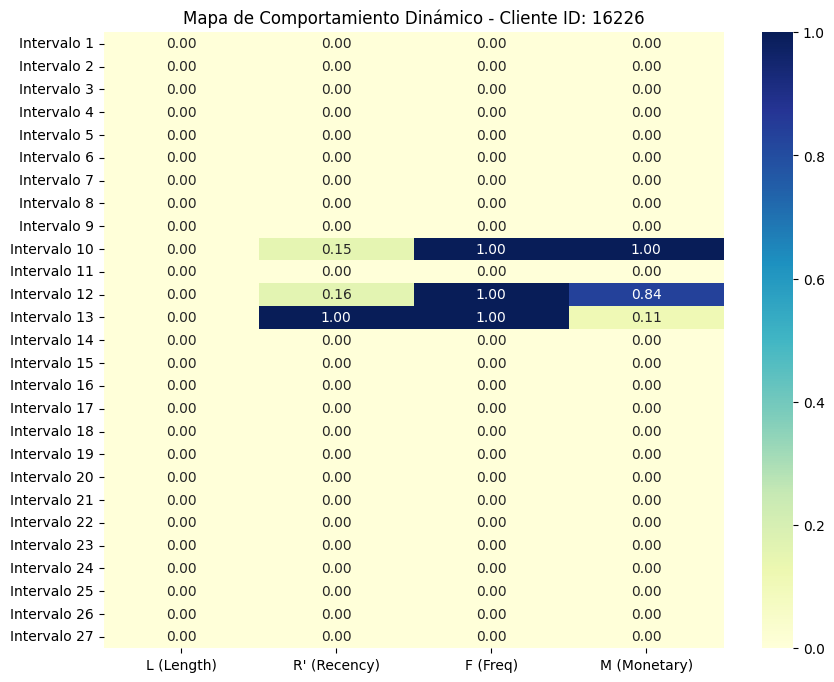

In [19]:
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def plot_heatmap_cliente_aleatorio(mts_dict):
    # 1. Seleccionar un ID de cliente al azar
    id_aleatorio = random.choice(list(mts_dict.keys()))
    
    # 2. Obtener su matriz (Intervalos x 4 variables) [cite: 13, 205]
    matriz = mts_dict[id_aleatorio]
    
    # 3. Validar que la matriz no esté vacía o tenga varianza para escalar
    if np.all(matriz == 0):
        print(f"El cliente {id_aleatorio} no tuvo actividad en los periodos seleccionados.")
        return
    
    # 4. Normalizar para que L, R, F, M sean comparables en el gráfico
    scaler = MinMaxScaler()
    matriz_norm = scaler.fit_transform(matriz)
    
    # 5. Crear el Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(matriz_norm, annot=True, fmt=".2f", cmap="YlGnBu",
                xticklabels=['L (Length)', "R' (Recency)", 'F (Freq)', 'M (Monetary)'],
                yticklabels=[f"Intervalo {i+1}" for i in range(matriz.shape[0])])
    
    plt.title(f"Mapa de Comportamiento Dinámico - Cliente ID: {id_aleatorio}")
    plt.show()

# Ejecutar para ver un cliente al azar
plot_heatmap_cliente_aleatorio(mts_resultados)

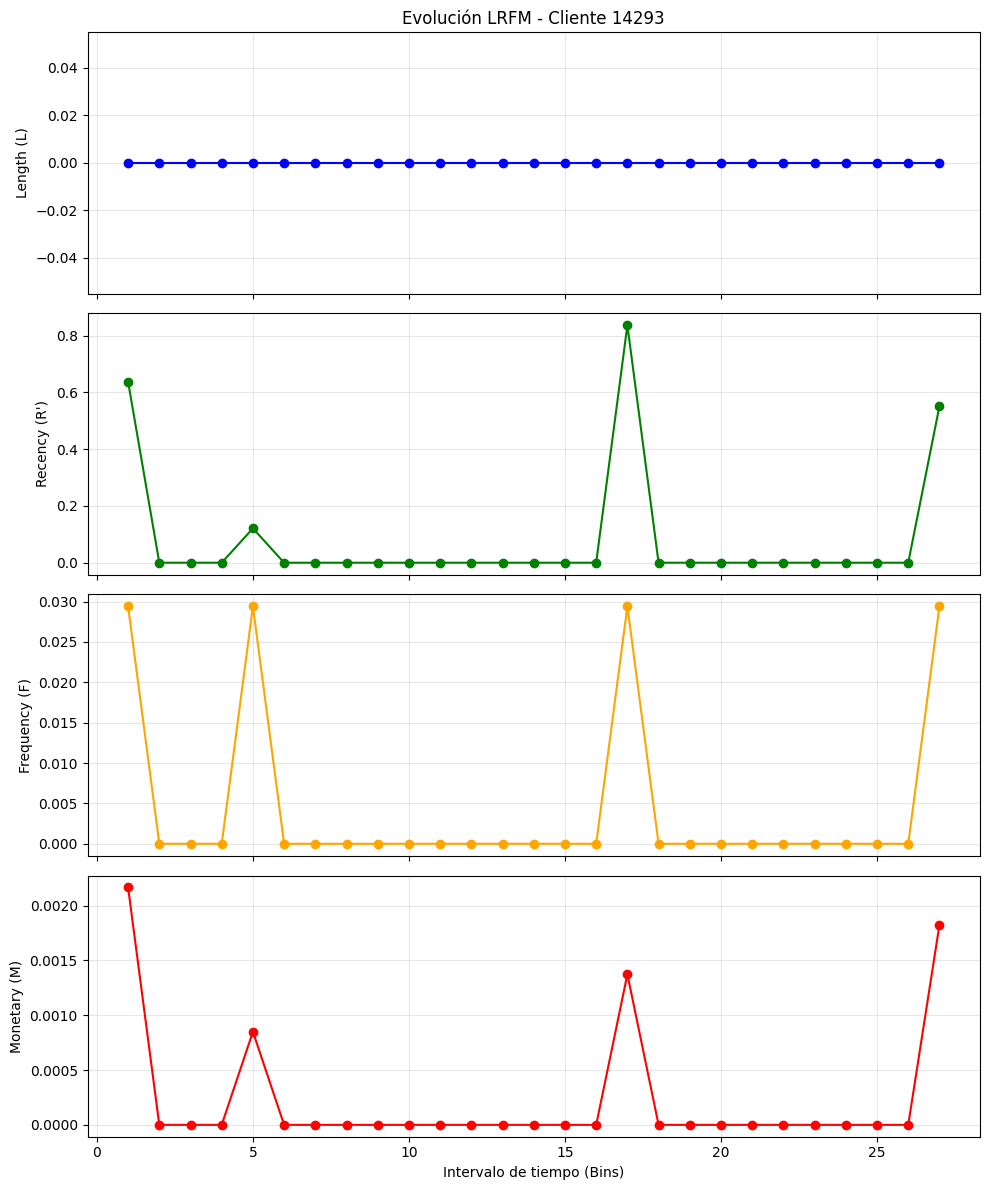

In [20]:
import matplotlib.pyplot as plt

def graficar_cliente(id_cliente, matrices_mts):
    # Extraemos la matriz del cliente (Time Steps x 4 métricas)
    data = matrices_mts[id_cliente]
    pasos_tiempo = range(1, len(data) + 1)
    
    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
    nombres = ['Length (L)', "Recency (R')", 'Frequency (F)', 'Monetary (M)']
    colores = ['blue', 'green', 'orange', 'red']
    
    for i in range(4):
        axes[i].plot(pasos_tiempo, data[:, i], marker='o', color=colores[i])
        axes[i].set_ylabel(nombres[i])
        axes[i].grid(True, alpha=0.3)
        if i == 0:
            axes[i].set_title(f"Evolución LRFM - Cliente {id_cliente}")
            
    plt.xlabel("Intervalo de tiempo (Bins)")
    plt.tight_layout()
    plt.show()

# Uso:
graficar_cliente(14293, mts_resultados)

In [21]:
from scipy.spatial.distance import cdist

# 1. Función para calcular pesos según la varianza/dispersión (Eq. 16 del estudio)
def calcular_pesos_lrfm(mts_dict):
    # Convertimos el diccionario a un array gigante (Clientes x Tiempo x Variables)
    todas_series = np.array(list(mts_dict.values()))

    # Dispersión por variable (suma de desviaciones absolutas respecto a la media)
    mean_vals = np.mean(todas_series, axis=(0, 1))
    dispersiones = np.sum(np.abs(todas_series - mean_vals), axis=(0, 1))

    # Normalizamos para que la suma de pesos sea 1
    pesos = dispersiones / np.sum(dispersiones)
    return pesos

# Pesos SOBRE datos normalizados (recomendado, como en el paper)
pesos_variables = calcular_pesos_lrfm(mts_resultados)
print(f"Pesos calculados sobre MTS normalizado (L, R, F, M): {pesos_variables}")

# (Opcional) Comparación: pesos sobre datos sin escalar (suele inflar Monetary)
pesos_variables_raw = calcular_pesos_lrfm(mts_resultados_raw)
print(f"Pesos calculados sobre MTS sin escalar (L, R, F, M): {pesos_variables_raw}")


Pesos calculados sobre MTS normalizado (L, R, F, M): [0.0820557  0.85216363 0.05994924 0.00583143]
Pesos calculados sobre MTS sin escalar (L, R, F, M): [0.00106945 0.01196074 0.00204348 0.98492634]


In [22]:
# --- PASO 7: APLICAR PESOS A LAS SERIES ---
def aplicar_pesos_a_mts(mts_norm_dict, pesos):
    mts_pesado = {}
    for cliente_id, matriz in mts_norm_dict.items():
        # Multiplicamos cada columna por su peso correspondiente [cite: 305]
        mts_pesado[cliente_id] = matriz * pesos
    return mts_pesado

mts_final = aplicar_pesos_a_mts(mts_resultados, pesos_variables)

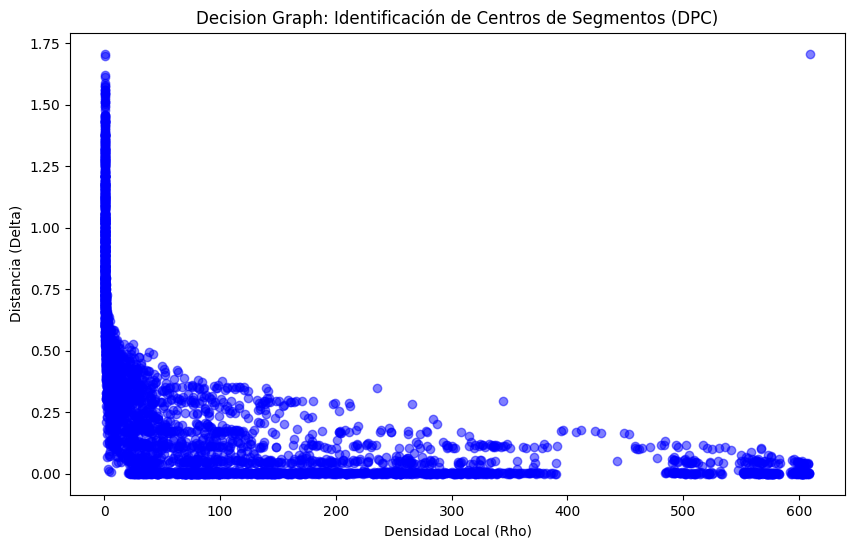

In [23]:
from sklearn.metrics import pairwise_distances

# 1. Aplanamos las matrices pesadas para el cálculo de densidad
# Cada cliente se convierte en un vector de (Bins * 4 variables)
X_clustering = np.array([matriz.flatten() for matriz in mts_final.values()])
cliente_ids = list(mts_final.keys())

# 2. Calculamos la matriz de distancias (Euclídea sobre series pesadas)
# El paper usa DTW-D, pero para 4000+ series la Euclídea pesada es un gran punto de partida
dist_matrix = pairwise_distances(X_clustering, metric='euclidean')

# 3. Algoritmo DPC (Density Peaks) [cite: 279]
def calcular_dpc(dist_matrix, dc_percentile=2):
    n = dist_matrix.shape[0]
    # Determinar cutoff distance (dc) [cite: 253]
    dc = np.percentile(dist_matrix, dc_percentile)
    
    # Calcular rho (Densidad local) 
    rho = np.sum(np.exp(-(dist_matrix / dc)**2), axis=1)
    
    # Calcular delta (Distancia al punto de mayor densidad) 
    delta = np.zeros(n)
    orden_rho = np.argsort(-rho) # Orden descendente de densidad
    
    for i in range(1, n):
        idx_i = orden_rho[i]
        # Puntos con mayor densidad que i
        mayores_rho = orden_rho[:i]
        delta[idx_i] = np.min(dist_matrix[idx_i, mayores_rho])
    
    # El punto de mayor densidad global tiene el delta máximo
    delta[orden_rho[0]] = np.max(delta)
    
    return rho, delta

rho, delta = calcular_dpc(dist_matrix)

# 4. Visualizar Decision Graph [cite: 277, 278]
plt.figure(figsize=(10, 6))
plt.scatter(rho, delta, alpha=0.5, c='blue')
plt.xlabel('Densidad Local (Rho)')
plt.ylabel('Distancia (Delta)')
plt.title('Decision Graph: Identificación de Centros de Segmentos (DPC)')
plt.show()